In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.optimize import minimize, Bounds
from GASModels.dynamics import Dynamics
from GASModels.distributions.gamma_log_link import GammaLogLinkDistribution
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution

In [2]:
xls = pd.read_csv('data/precipitation.csv')

In [3]:
# Create dynamics object
dynamics = Dynamics(
    distribution=ZAGB2LogLinkDistribution(),
    n=len(xls['precipitation'][0:730]),
    trend=None,
    seasonality=None,
    harmonics=20,
    period=365.25,
    time_varying_indices=[0],
    fixed_params_indices=[1],
    args=[0.05, 0.02]
)


In [22]:
def objective_function(params, y, distribution):
    """
    Proper objective function: negative log-likelihood
    """
    # Unpack parameters - ZAGB2 needs 6 parameters
    delta_0, delta_1, gamma, xi, zeta = params
    delta_0 = delta_0 / 100
    delta_1 = delta_1 / 100
    gamma = gamma / 100
    xi = xi / 100
    zeta = zeta / 100
    phi = np.ones(len(y))
    
    total_loglik = 0.0
    
    for t in range(len(y)):
        try:
            if phi[t] <= 0 or gamma <= 0 or xi <= 0 or zeta <= 0:
                return np.inf
            if np.exp(zeta) <= np.exp(gamma):
                return np.inf
            loglik = distribution.logpdf(
                y[t],
                delta_0=delta_0,
                delta_1=delta_1, 
                phi=phi[t],
                gamma=gamma,
                xi=xi,
                zeta=zeta
            )
            total_loglik += loglik
        except:
            # Return large value if numerical issues
            return 1e10
    
    # Return negative log-likelihood for minimization
    return -total_loglik

# Initial guess for all 6 parameters
initial_guess = [100, 100, 10, 50, 100]  # delta_0, delta_1, phi, gamma, xi, zeta

result = minimize(
    objective_function,
    x0=initial_guess,
    args=(xls['precipitation'][0:730], ZAGB2LogLinkDistribution()),
    method='BFGS',
    options={
        'gtol': 1e-1,
        'maxiter': 1000,
        'disp': True
    }
)

         Current function value: 1757.876260
         Iterations: 3
         Function evaluations: 83
         Gradient evaluations: 13


c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [23]:
result

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 1757.8762604053502
        x: [ 5.854e+01  5.854e+01  4.577e+01  7.632e+01  4.626e+01]
      nit: 3
      jac: [ 1.783e+00  1.783e+00  8.387e-01  9.247e-01 -1.357e+00]
 hess_inv: [[ 7.120e+00  6.120e+00 ... -2.479e+00  5.388e+00]
            [ 6.120e+00  7.120e+00 ... -2.479e+00  5.388e+00]
            ...
            [-2.479e+00 -2.479e+00 ...  2.043e+00 -2.269e+00]
            [ 5.388e+00  5.388e+00 ... -2.269e+00  5.922e+00]]
     nfev: 83
     njev: 13

In [4]:
initial_params = dynamics.get_initial_values(xls['precipitation'][0:730])

Initial parameter check:
km: 50 (bounds: 1-2000) - OK
kg: 20 (bounds: 1-2000) - OK
gamma_0: 0.0 (bounds: -200-200) - OK
mu0: 10 (bounds: -1000-1000) - OK
delta_0: 100 (bounds: -200-200) - OK
delta_1: 100 (bounds: -100-100) - OK
gamma_: 33 (bounds: 10-500) - OK
xi: 68 (bounds: 10-500) - OK
zeta: 66 (bounds: 20-1000) - OK
zeta > gamma_: True - OK


In [5]:
initial_params

array([ 50.,  20.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  10., 100.,
       100.,  33.,  68.,  66.])

In [ ]:
bounds = [
    # km, kg - learning rates (will be divided by 1000)
    (-2000, 2000),      # km: results in 0.001 to 2.0 after scaling
    (-2000, 2000),      # kg: results in 0.001 to 2.0 after scaling
] + [
    # 40 seasonal parameters (20 gamma + 20 gamma_star)
    (-200, 200) for _ in range(40)
] + [
    # 6 distribution parameters
    (-1000, 1000),  # mu0: results in -10.0 to 10.0 after scaling
    (-2000, 2000),    # delta_0: results in -2.0 to 2.0 after scaling  
    (-1000, 1000),    # delta_1: results in -1.0 to 1.0 after scaling
    (0, 500),      # gamma_: results in 0.1 to 5.0 after scaling (must be > 0)
    (0, 500),      # xi: results in 0.1 to 5.0 after scaling (must be > 0)
    (0, 1000)      # zeta: results in 0.2 to 10.0 after scaling (must be > gamma_)
]

# Test the objective function first
print("Testing objective function with initial parameters...")
test_value = dynamics.objective(initial_params, xls['precipitation'][0:730], bounds)
print(f"Initial objective value: {test_value}")

if np.isinf(test_value):
    print("CRITICAL: Objective returns inf even with initial parameters")
    print("Debugging step by step...")
    
    # Test with even simpler parameters
    simple_params = np.array([
        20, 20,                           # km, kg
        *[0] * 80,                         # seasonal  
        0, 10, 5, 33, 68, 66          # distribution
    ])
    
    simple_test = dynamics.objective(simple_params, xls['precipitation'][0:10], bounds)  # Small sample
    print(f"Simple test: {simple_test}")
else:
    # Only run optimization if initial test passes
    result = minimize(
        dynamics.objective,
        x0=initial_params,
        args=(xls['precipitation'][0:730], bounds),
        method='BFGS',
        options={
            'gtol': 1e-3,
            'maxiter': 100,
            'disp': True
        }
    )

Testing objective function with initial parameters...
Initial objective value: 2.579768251803833


c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\za_gb2_log_link.py:77: RuntimeWarning: invalid value encountered in log
  * (np.log(y - phi))


Parameter 44 out of bounds: 100.00000001490116 not in [-100, 100]
         Current function value: 2.579768
         Iterations: 0
         Function evaluations: 161
         Gradient evaluations: 3


c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:1440: RuntimeWarning: invalid value encountered in dot
  pk = -np.dot(Hk, gfk)
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:574: RuntimeWarning: invalid value encountered in subtract
  dx = ((x0 + h) - x0)
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:685: RuntimeWarning: invalid value encountered in scalar subtract
  dx = [(x0[i] + h[i]) - x0[i] for i in range(n)]
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:574: RuntimeWarning: invalid value encountered in subtract
  dx = ((x0 + h) - x0)
c:\Users\ilang\AppData\Local\Programs\

In [7]:
result

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 2.579768251803833
        x: [ 5.000e+01  2.000e+01 ...  6.800e+01  6.600e+01]
      nit: 0
      jac: [-2.018e-05  2.526e-03 ... -3.308e-03  5.320e-03]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 161
     njev: 3

In [8]:
dynamics.objective(result['x'], xls['precipitation'][0:730], bounds)

c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\za_gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  linear_comb = delta_0 + delta_1 * np.exp(phi)
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\za_gb2_log_link.py:33: RuntimeWarning: invalid value encountered in scalar subtract
  pi = np.exp(linear_comb - max_val) / (1 + np.exp(linear_comb - max_val))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\za_gb2_log_link.py:51: RuntimeWarning: overflow encountered in exp
  z = (y_safe / np.exp(phi)) ** exponent


np.float64(736.8791129270771)

In [8]:
result['x']

array([ 50.,  20.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  10., 100.,
       100.,  33.,  68.,  66.])

In [9]:
result['jac']

array([-2.01761723e-05,  2.52553821e-03, -4.24385071e-05, -1.41263008e-05,
       -4.15146351e-05, -5.40614128e-05,  6.93202019e-05, -1.14738941e-05,
       -5.30481339e-05,  9.41753387e-05, -1.21295452e-05,  5.73098660e-05,
        5.55217266e-05, -2.95937061e-05,  6.51478767e-05, -5.06043434e-05,
       -7.76052475e-05,  1.05172396e-04, -9.11056995e-05,  1.82092190e-05,
       -6.26146793e-05, -2.30699778e-04,  4.68790531e-05, -1.21295452e-05,
       -4.18722630e-05,  4.58955765e-06, -3.46302986e-05, -2.86996365e-05,
        9.86456871e-06,  7.06911087e-05,  2.70009041e-05,  2.08914280e-05,
        4.05311584e-06,  6.48200512e-05, -8.49664211e-05, -1.89542770e-05,
       -3.44216824e-05, -1.44273043e-04,  1.88946724e-05, -3.49581242e-05,
       -7.45058060e-07, -3.22163105e-05,  1.16229057e-06,  2.41404772e-03,
                   inf, -2.98118591e-03, -3.30796838e-03,  5.32042980e-03])

In [10]:
fis = result['x']

In [11]:
fis

array([ 50.,  20.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  10., 100.,
       100.,  33.,  68.,  66.])

In [12]:
y = dynamics.fit_in_sample(fis, xls['precipitation'][0:730])

c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\za_gb2_log_link.py:77: RuntimeWarning: invalid value encountered in log
  * (np.log(y - phi))


In [27]:
y

array([151.05750112, 145.19945432, 138.51175202, 131.37114821,
       124.16239535, 135.89883541, 151.22166911, 155.54766034,
       151.32343109, 146.31185935, 140.71125367, 134.74882925,
       128.65689422, 122.65215676, 116.92055742, 128.83777394,
       125.06106487, 124.7756491 , 128.80806425, 146.43944274,
       151.3658328 , 177.31657543, 196.36781383, 212.80246136,
       208.1318086 , 199.65875611, 195.91619792, 195.34478373,
       195.06197275, 209.28357777, 212.08263205, 197.97684597,
       184.20398299, 182.75643818, 195.65585825, 214.03945611,
       199.01038887, 207.5803524 , 207.64100851, 220.43230182,
       195.12909107, 179.21333925, 156.14273442, 144.45627499,
       134.1117111 , 122.30425102, 115.01015895, 109.3846583 ,
       105.31896959, 115.25655907, 109.29698073, 109.01117471,
       104.1175837 , 103.95076147, 103.82928553, 116.30885315,
       132.68489023, 126.5538539 , 140.42550545, 138.80670324,
       135.16345209, 149.09632925, 143.76296338, 137.05

In [14]:
np.exp(0.998) * (y / np.exp(9.953) - 1)

array([-2.64987361, -2.64755952, -2.64559954, -2.64407762, -2.64305352,
       -2.64077992, -2.63877011, -2.64003817, -2.64087125, -2.64215872,
       -2.64380531, -2.64570423, -2.64774587, -2.64982564, -2.65185024,
       -2.65206514, -2.65359798, -2.6562992 , -2.65787394, -2.6569666 ,
       -2.65797356, -2.65605799, -2.65459178, -2.65314059, -2.65259381,
       -2.65355191, -2.65362757, -2.65315318, -2.65261976, -2.6506407 ,
       -2.64989994, -2.65008778, -2.65213795, -2.65264667, -2.65169024,
       -2.65046425, -2.6535306 , -2.65349543, -2.6544562 , -2.65391578,
       -2.65789224, -2.66067107, -2.66441595, -2.66544061, -2.66614648,
       -2.66826983, -2.66854853, -2.66850116, -2.66815153, -2.66634264,
       -2.66775121, -2.66691902, -2.6683221 , -2.66758443, -2.66675641,
       -2.66469814, -2.662183  , -2.66372548, -2.66175444, -2.66098074,
       -2.66034752, -2.65811893, -2.65755189, -2.65716486, -2.65694442,
       -2.65626999, -2.6593885 , -2.65983168, -2.66026355, -2.66

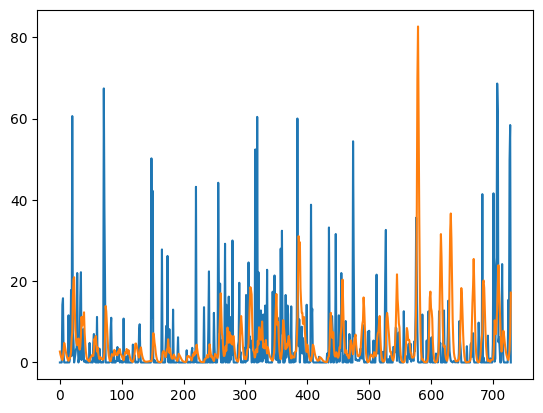

In [13]:
plt.plot(xls['precipitation'][0:730])
plt.plot(y)

In [13]:
fis

array([20., 20.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.,  5., 33.,
       68., 66.])

In [14]:
pit = dynamics.pit(fis, xls['precipitation'][0:730])

In [15]:
pit

array([0.24973989, 0.31812913, 0.39933751, 0.48422818, 0.99525965,
       0.98512224, 0.68777946, 0.15724264, 0.17956548, 0.21889837,
       0.27834741, 0.3577975 , 0.45048799, 0.54370292, 0.99622997,
       0.4455965 , 0.86181527, 0.84237843, 0.9682897 , 0.46229326,
       0.96928469, 0.54254059, 0.40201957, 0.04098036, 0.18297375,
       0.41941464, 0.63134778, 0.70933871, 0.95266184, 0.71709125,
       0.13174939, 0.50853503, 0.77968048, 0.94053086, 0.92081348,
       0.15897718, 0.64260999, 0.37670924, 0.68516003, 0.08868598,
       0.23601228, 0.21919233, 0.2523231 , 0.38102793, 0.77502694,
       0.51670787, 0.60214956, 0.66103078, 0.99369411, 0.64225261,
       0.39554245, 0.52403757, 0.33037929, 0.33543137, 0.93182616,
       0.88885245, 0.18107989, 0.79264596, 0.12099374, 0.16874687,
       0.94470732, 0.19357931, 0.28382727, 0.39915957, 0.96375744,
       0.55014706, 0.41658544, 0.47121245, 0.51541552, 0.72123127,
       0.4845437 , 0.99902368, 0.98894093, 0.91059545, 0.06054

In [ ]:
p

In [14]:
np.min(pit)

np.float64(0.35401177737089495)

In [18]:
np.max(pit)

np.float64(0.994483525611721)

In [16]:
np.sum(pit < 0.5)

np.int64(390)

(array([ 58.,  72.,  77.,  82.,  59.,  66.,  54.,  66.,  60., 136.]),
 array([0.01251104, 0.11123697, 0.20996289, 0.30868882, 0.40741474,
        0.50614067, 0.60486659, 0.70359252, 0.80231844, 0.90104437,
        0.99977029]),
 <BarContainer object of 10 artists>)

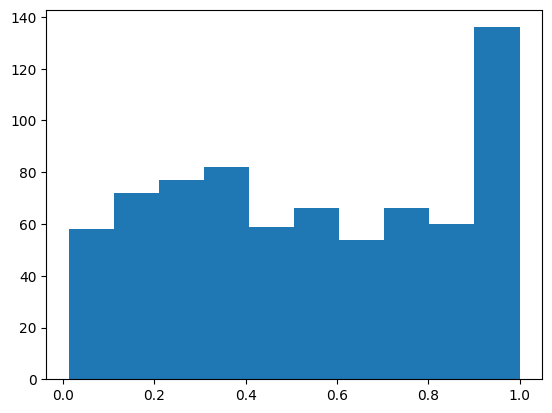

In [16]:
plt.hist(pit)

In [18]:
quant = dynamics.get_quantile_residuals(pit)

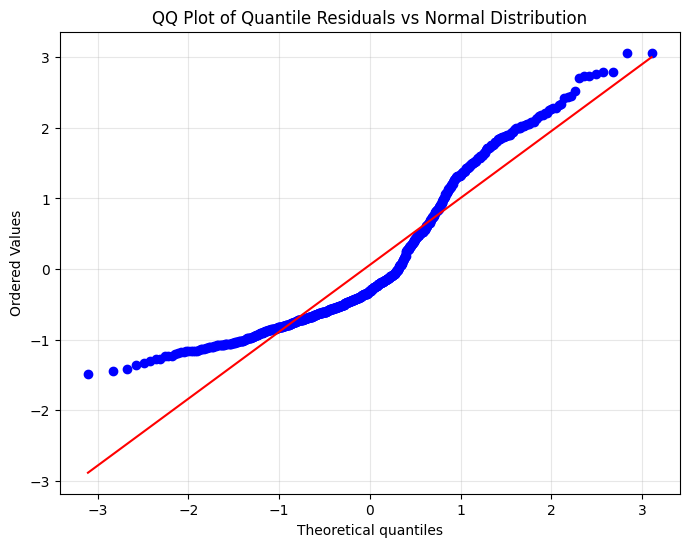

In [19]:
# Create QQ plot
plt.figure(figsize=(8, 6))
stats.probplot(quant, dist="norm", plot=plt)
plt.title('QQ Plot of Quantile Residuals vs Normal Distribution')
plt.grid(True, alpha=0.3)
plt.show()